

1. Setup & Data Preparation
This keeps your existing logic but filters the data generation to focus on the 'High' column and specific days.



In [3]:
# --- Step 1: Import Libraries & Load Data ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional
import warnings

warnings.filterwarnings("ignore")

# Load the dataset (Make sure data.csv is uploaded to Colab)
try:
    df = pd.read_csv('data.csv')
    print("✅ Data loaded successfully!")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Total Rows: {len(df)}")
except FileNotFoundError:
    print("❌ Error: 'data.csv' not found. Please upload the file to Colab files.")

✅ Data loaded successfully!
Columns: ['Date', 'Open', 'High', 'Low', 'Close']
Total Rows: 6315


2. Model Definitions
We filter your ML list to just KNN and keep your Deep Learning builders.

In [4]:
# --- Step 2: Data Processing ---

def return_pairs(column, days):
    pricess = list(column)
    X = []
    y = []
    for i in range(len(pricess) - days):
        X.append(pricess[i:i+days])
        y.append(pricess[i+days])
    return np.array(X), np.array(y)

# Assignment Configuration
target_col = 'High'
assignment_days = [30, 60, 90]

# Generate Datasets
assignment_data = {}
print(f"Preparing data for target: '{target_col}'...")

for days in assignment_days:
    key_X = f"X_{days}"
    key_y = f"y_{days}"

    # Create windows
    X, y = return_pairs(df[target_col], days)

    # Store in dictionary
    assignment_data[key_X] = X
    assignment_data[key_y] = y

    print(f"  -> Created window {days} days: {X.shape}")

print("✅ Data preparation complete.")

Preparing data for target: 'High'...
  -> Created window 30 days: (6285, 30)
  -> Created window 60 days: (6255, 60)
  -> Created window 90 days: (6225, 90)
✅ Data preparation complete.


3. Training Loop (The Main Process)
This is the critical step. I have updated the loop to run 50 epochs for DL models and iterate only through the required 30, 60, and 90-day windows.

In [5]:
# --- Step 3: Define Models ---

# 1. Dictionary for Deep Learning Builders
def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(50, activation='tanh'), input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

dl_builders = {
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "Bi-LSTM": build_bilstm
}

print("✅ Model architectures defined.")

✅ Model architectures defined.


4. Comparison & Evaluation
This code compiles the results into a table and creates a grouped bar chart to compare the models across the three time windows.

In [6]:
# --- Step 4: Optimized Training Loop ---
import tensorflow as tf

# Check if GPU is available
if tf.test.gpu_device_name():
    print('✅ GPU detected! Training will be fast.')
else:
    print('⚠️ No GPU detected. Go to Runtime > Change runtime type > T4 GPU to speed this up.')

assignment_results = []
trained_models = {}

print("🚀 Starting training process...")

# Iterate through time windows
for days in tqdm(assignment_days, desc="Time Windows"):

    # 1. Get Data
    X = assignment_data[f"X_{days}"]
    y = assignment_data[f"y_{days}"]

    # 2. Split Data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42
    )

    # --- A. Train KNN (Fast) ---
    knn = KNeighborsRegressor()
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)

    assignment_results.append({
        "Model": "KNN",
        "Window": days,
        "Test MAE": mean_absolute_error(y_test, y_pred_knn),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_knn))
    })

    # --- B. Train Deep Learning Models (Optimized) ---
    # Reshape for DL
    X_train_dl = np.expand_dims(X_train, -1)
    X_test_dl = np.expand_dims(X_test, -1)

    for name, builder in dl_builders.items():
        # Build Model
        model = builder((X_train.shape[1], 1))

        # Train
        # OPTIMIZATION: batch_size=64 (Faster than 16/32)
        model.fit(X_train_dl, y_train, epochs=50, batch_size=64, verbose=0)

        # Predict
        y_pred_dl = model.predict(X_test_dl, verbose=0).flatten()

        # Store Results
        assignment_results.append({
            "Model": name,
            "Window": days,
            "Test MAE": mean_absolute_error(y_test, y_pred_dl),
            "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_dl))
        })

print("✅ Training complete.")

✅ GPU detected! Training will be fast.
🚀 Starting training process...


Time Windows:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Training complete.


Step 5: Evaluation & Visualization
Generates the final dataframe and a comparison chart.


📊 Final Assignment Results (Best to Worst):
| Model   |   Window |   Test MAE |   Test RMSE |
|:--------|---------:|-----------:|------------:|
| KNN     |       90 |    48.7901 |     74.2048 |
| KNN     |       60 |    52.8191 |     82.6746 |
| KNN     |       30 |    56.933  |     89.6794 |
| RNN     |       30 |  7196.88   |   9513.03   |
| RNN     |       60 |  7264.69   |   9464.03   |
| GRU     |       30 |  7293.71   |   9586.49   |
| Bi-LSTM |       30 |  7297.31   |   9589.23   |
| Bi-LSTM |       60 |  7341.6    |   9523.2    |
| GRU     |       60 |  7365.02   |   9541.26   |
| LSTM    |       30 |  7370.89   |   9645.35   |
| LSTM    |       60 |  7414.47   |   9579.48   |
| RNN     |       90 |  7453.68   |   9680.92   |
| Bi-LSTM |       90 |  7549.86   |   9755.16   |
| GRU     |       90 |  7574.88   |   9774.53   |
| LSTM    |       90 |  7637.44   |   9823.1    |


<Figure size 1200x600 with 0 Axes>

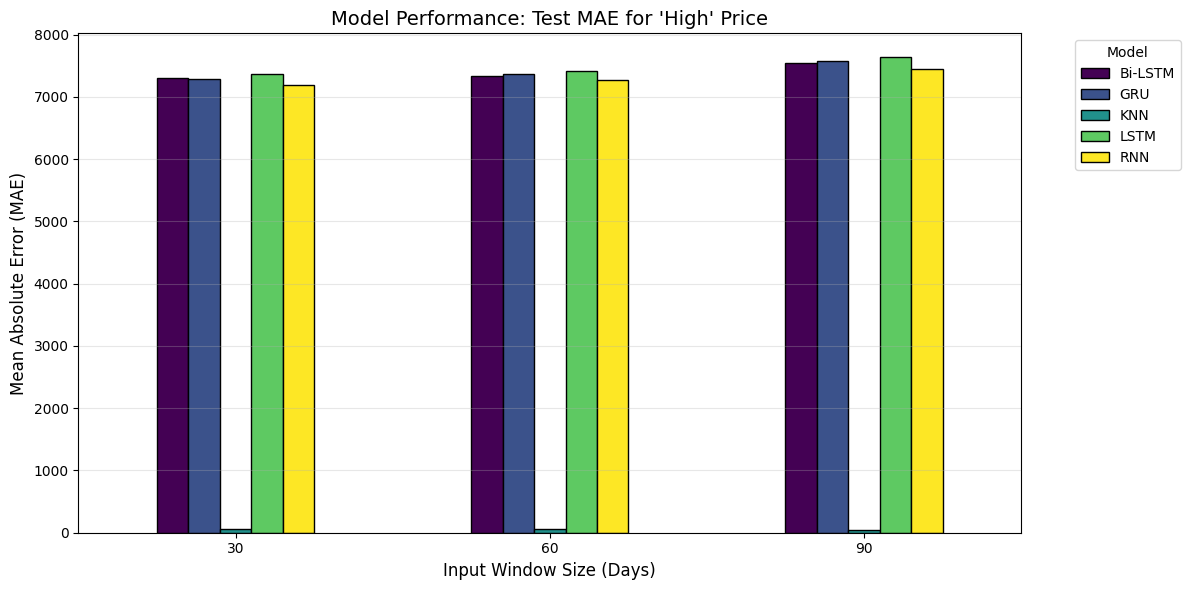

✅ Results saved to 'assignment_results.csv'


In [7]:
# --- Step 5: Results & Visualization ---

# Create DataFrame
results_df = pd.DataFrame(assignment_results)

# 1. Show Leaderboard (Sorted by Error)
print("\n📊 Final Assignment Results (Best to Worst):")
display_df = results_df.sort_values(by="Test MAE")
print(display_df.to_markdown(index=False))

# 2. Visualize Comparison
pivot_df = results_df.pivot(index="Window", columns="Model", values="Test MAE")

plt.figure(figsize=(12, 6))
pivot_df.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')

plt.title(f"Model Performance: Test MAE for '{target_col}' Price", fontsize=14)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=12)
plt.xlabel("Input Window Size (Days)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Save results to CSV
results_df.to_csv("assignment_results.csv", index=False)
print("✅ Results saved to 'assignment_results.csv'")